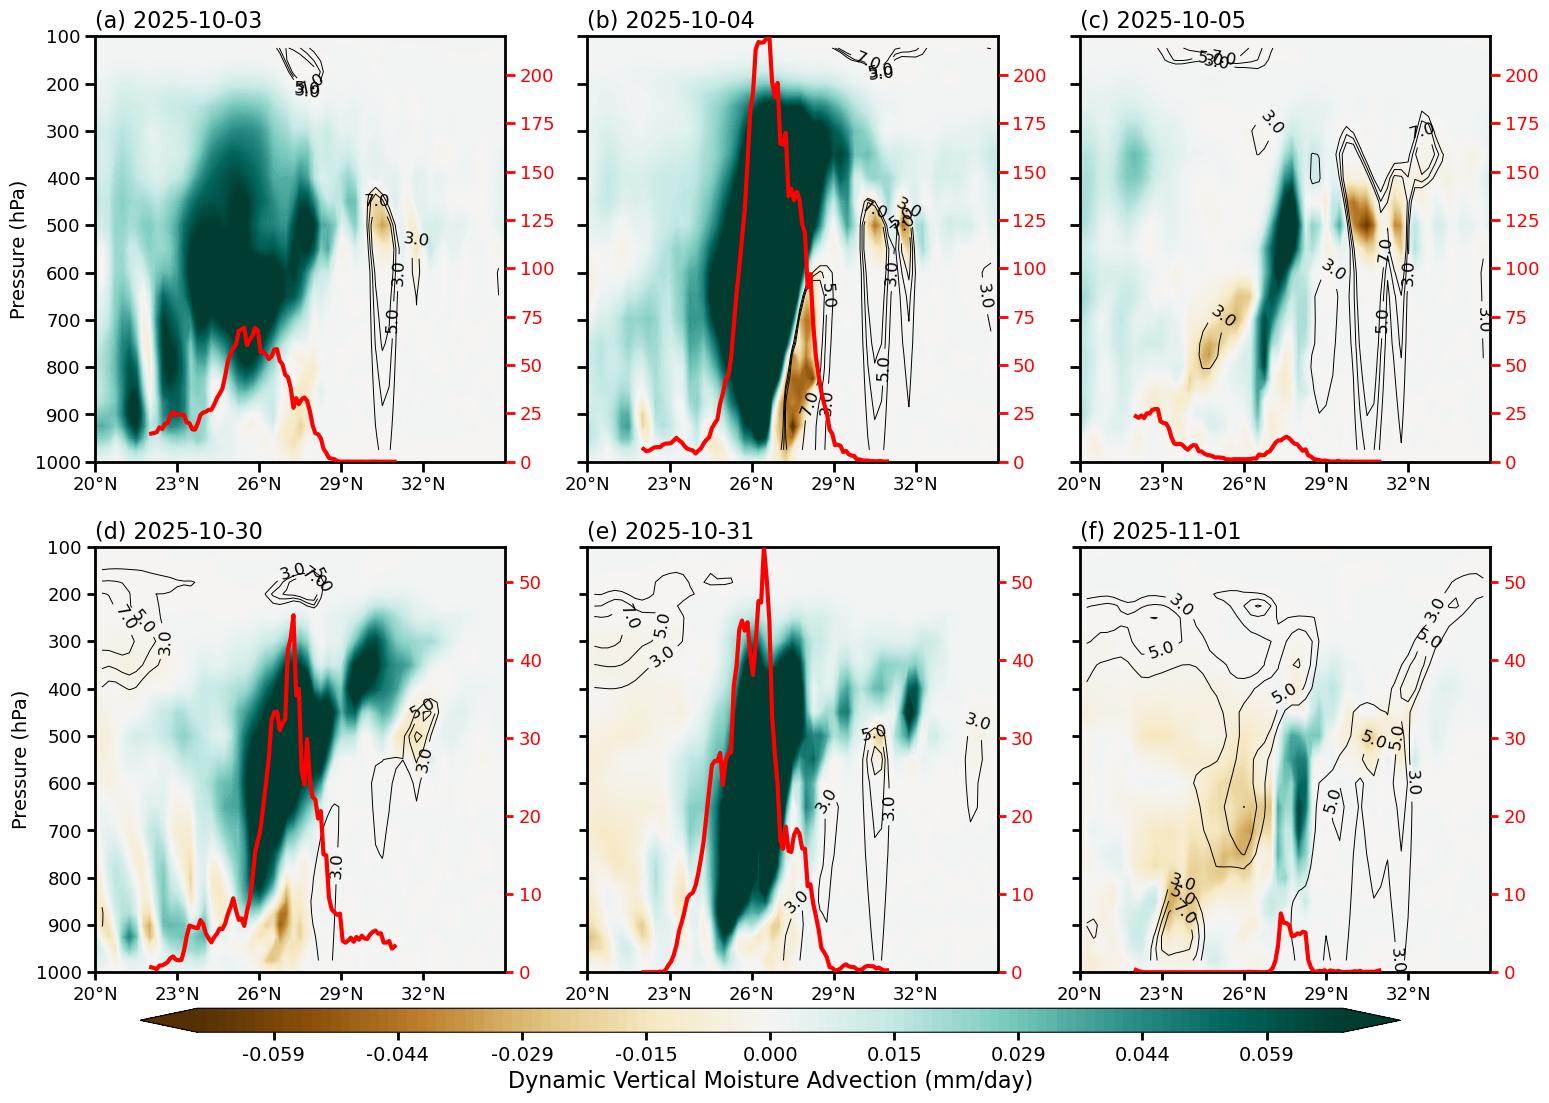

In [4]:

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# CONSTANTS
g = 9.81
sec_day = 86400.0
earth_radius = 6.371e6

# FUNCTIONS
def process_era(era, time_coord='valid_time'):
    era = era.sortby("pressure_level", ascending=False)
    era = era.sel(longitude=slice(84,88), latitude=slice(35,20))

    q = era['q']
    omega = era['w']
    T = era['t']
    u = era['u']
    v = era['v']

    dq_dp = q.differentiate('pressure_level')
    dyn = -(omega * dq_dp) / g * sec_day
    dyn_cross = dyn.mean(dim='longitude')

    dT_dt = T.differentiate(time_coord) * sec_day
    lat_rad = np.deg2rad(era.latitude)
    dx = earth_radius * np.cos(lat_rad) * np.deg2rad(1)
    dy = earth_radius * np.deg2rad(1)

    dT_dx = T.differentiate('longitude') / dx
    dT_dy = T.differentiate('latitude') / dy

    adv_h = u * dT_dx + v * dT_dy
    dT_dp = T.differentiate('pressure_level') / 100.0
    adv_v = omega * dT_dp

    Q1 = (dT_dt + adv_h + adv_v) * sec_day
    Q1_cross = Q1.mean(dim='longitude')

    Q1_cross = Q1_cross.sortby("latitude")
    Q1_cross = Q1_cross.sortby("pressure_level", ascending=True)
    Q1_cross = Q1_cross.interpolate_na("pressure_level")
    Q1_cross = Q1_cross.interpolate_na("latitude")
    Q1_cross = Q1_cross.rolling(latitude=3, pressure_level=3, center=True).mean()
    Q1_cross = Q1_cross.sortby("pressure_level", ascending=False)

    return dyn_cross, Q1_cross


def load_rain(path):
    rain = xr.open_dataset(path)['precipitation']
    rain = rain.sortby('time')
    rain = rain.sel(lon=slice(84,88))

    if rain.lat[0] > rain.lat[-1]:
        rain = rain.sel(lat=slice(31,22))
    else:
        rain = rain.sel(lat=slice(22,31))

    rain_daily = rain.resample(time='1D').sum()
    rain_zonal = rain_daily.mean(dim='lon')

    return rain_zonal


# LOAD DATA
era1 = xr.open_dataset("/Users/beekenshrestha/Downloads/RESEARCH/oct4/advection_4.nc")
dyn1, Q1_1 = process_era(era1)

rain1 = load_rain("/Users/beekenshrestha/Downloads/RESEARCH/oct4/MSWEP/merged.nc")

era2 = xr.open_dataset(
    "/Users/beekenshrestha/Downloads/RESEARCH/oct4/advection_31.grib",
    engine="cfgrib",
    backend_kwargs={"filter_by_keys": {"typeOfLevel": "isobaricInhPa"}}
)

if "isobaricInhPa" in era2.coords:
    era2 = era2.rename({"isobaricInhPa": "pressure_level"})
if "lat" in era2.coords:
    era2 = era2.rename({"lat": "latitude"})
if "lon" in era2.coords:
    era2 = era2.rename({"lon": "longitude"})

dyn2, Q1_2 = process_era(era2, time_coord='time')

rain2 = load_rain("/Users/beekenshrestha/Downloads/RESEARCH/oct4/MSWEP31/merged.nc")

# ✅ ROW-WISE FIXED LIMITS
rain1_min, rain1_max = float(rain1.min()), float(rain1.max())
rain2_min, rain2_max = float(rain2.min()), float(rain2.max())

# COLOR LEVELS
vmax = np.nanpercentile(np.abs(
    np.concatenate([dyn1.values.flatten(), dyn2.values.flatten()])
), 95)

dyn_levels = np.linspace(-vmax, vmax, 121)
Q1_levels = np.arange(3, 7.1 + 0.01, 2)

panel_labels = list("abcdef")

dates_row1 = ["2025-10-03","2025-10-04","2025-10-05"]
dates_row2 = ["2025-10-30","2025-10-31","2025-11-01"]



fig, axes = plt.subplots(2, 3, figsize=(18,12), sharey=True)

lat_ticks  = np.arange(20,35,3)
pres_ticks = np.arange(1000, 99, -100)

# ---- Top row ----
for i, day in enumerate(dates_row1):
    ax1 = axes[0, i]

    dyn_day = dyn1.sel(valid_time=day).mean('valid_time')
    Q1_day  = Q1_1.sel(valid_time=day).mean('valid_time')

    cf = ax1.contourf(dyn_day.latitude, dyn_day.pressure_level,
                      dyn_day, levels=dyn_levels, cmap='BrBG', extend='both')

    ax1.set_ylim(1000, 100)

    cs = ax1.contour(Q1_day.latitude, Q1_day.pressure_level,
                     Q1_day, levels=Q1_levels, colors='black', linewidths=0.7)

    ax1.clabel(cs, fmt="%.1f", fontsize=12)

    rain_day = rain1.sel(time=day)

    ax2 = ax1.twinx()
    ax2.plot(rain_day.lat, rain_day, color='red', linewidth=3)

    # ✅ SAME RANGE for all top panels
    ax2.set_ylim(rain1_min, rain1_max)

    ax2.tick_params(axis='y', colors='red', labelsize=13, width=2, length=7)

    ax1.set_xticks(lat_ticks)
    ax1.set_xticklabels([f"{lat}°N" for lat in lat_ticks], fontsize=12)
    ax1.set_yticks(pres_ticks)

    ax1.tick_params(axis='both', labelsize=13, width=2, length=7)

    for s in ax1.spines.values():
        s.set_linewidth(2)

    ax1.set_title(f"({panel_labels[i]}) {day}", loc='left', fontsize=16)

# ---- Bottom row ----
for i, day in enumerate(dates_row2):
    ax1 = axes[1, i]

    dyn_day = dyn2.sel(time=day).mean('time')
    Q1_day  = Q1_2.sel(time=day).mean('time')

    cf = ax1.contourf(dyn_day.latitude, dyn_day.pressure_level,
                      dyn_day, levels=dyn_levels, cmap='BrBG', extend='both')

    ax1.set_ylim(1000, 100)

    cs = ax1.contour(Q1_day.latitude, Q1_day.pressure_level,
                     Q1_day, levels=Q1_levels, colors='black', linewidths=0.7)

    ax1.clabel(cs, fmt="%.1f", fontsize=12)

    rain_day = rain2.sel(time=day)

    ax2 = ax1.twinx()
    ax2.plot(rain_day.lat, rain_day, color='red', linewidth=3)

    # ✅ SAME RANGE for all bottom panels
    ax2.set_ylim(rain2_min, rain2_max)

    ax2.tick_params(axis='y', colors='red', labelsize=13, width=2, length=6)

    ax1.set_xticks(lat_ticks)
    ax1.set_xticklabels([f"{lat}°N" for lat in lat_ticks], fontsize=12)
    ax1.set_yticks(pres_ticks)

    ax1.tick_params(axis='both', labelsize=13, width=2, length=6)

    for s in ax1.spines.values():
        s.set_linewidth(2)

    ax1.set_title(f"({panel_labels[i+3]}) {day}", loc='left', fontsize=16)

axes[0,0].set_ylabel("Pressure (hPa)", fontsize=14)
axes[1,0].set_ylabel("Pressure (hPa)", fontsize=14)

# COLORBAR
plt.subplots_adjust(bottom=0.1)
cax = fig.add_axes([0.15,0.05,0.7,0.02])

cbar = fig.colorbar(cf, cax=cax, orientation='horizontal',
                    format=FormatStrFormatter('%.3f'))

cbar.set_label("Dynamic Vertical Moisture Advection (mm/day)", fontsize=16)
cbar.ax.tick_params(labelsize=14, width=2, length=6)

plt.savefig("/Users/beekenshrestha/Downloads/RESEARCH/oct4/output/2event_Advection.png",
            dpi=450, bbox_inches='tight')

plt.show()


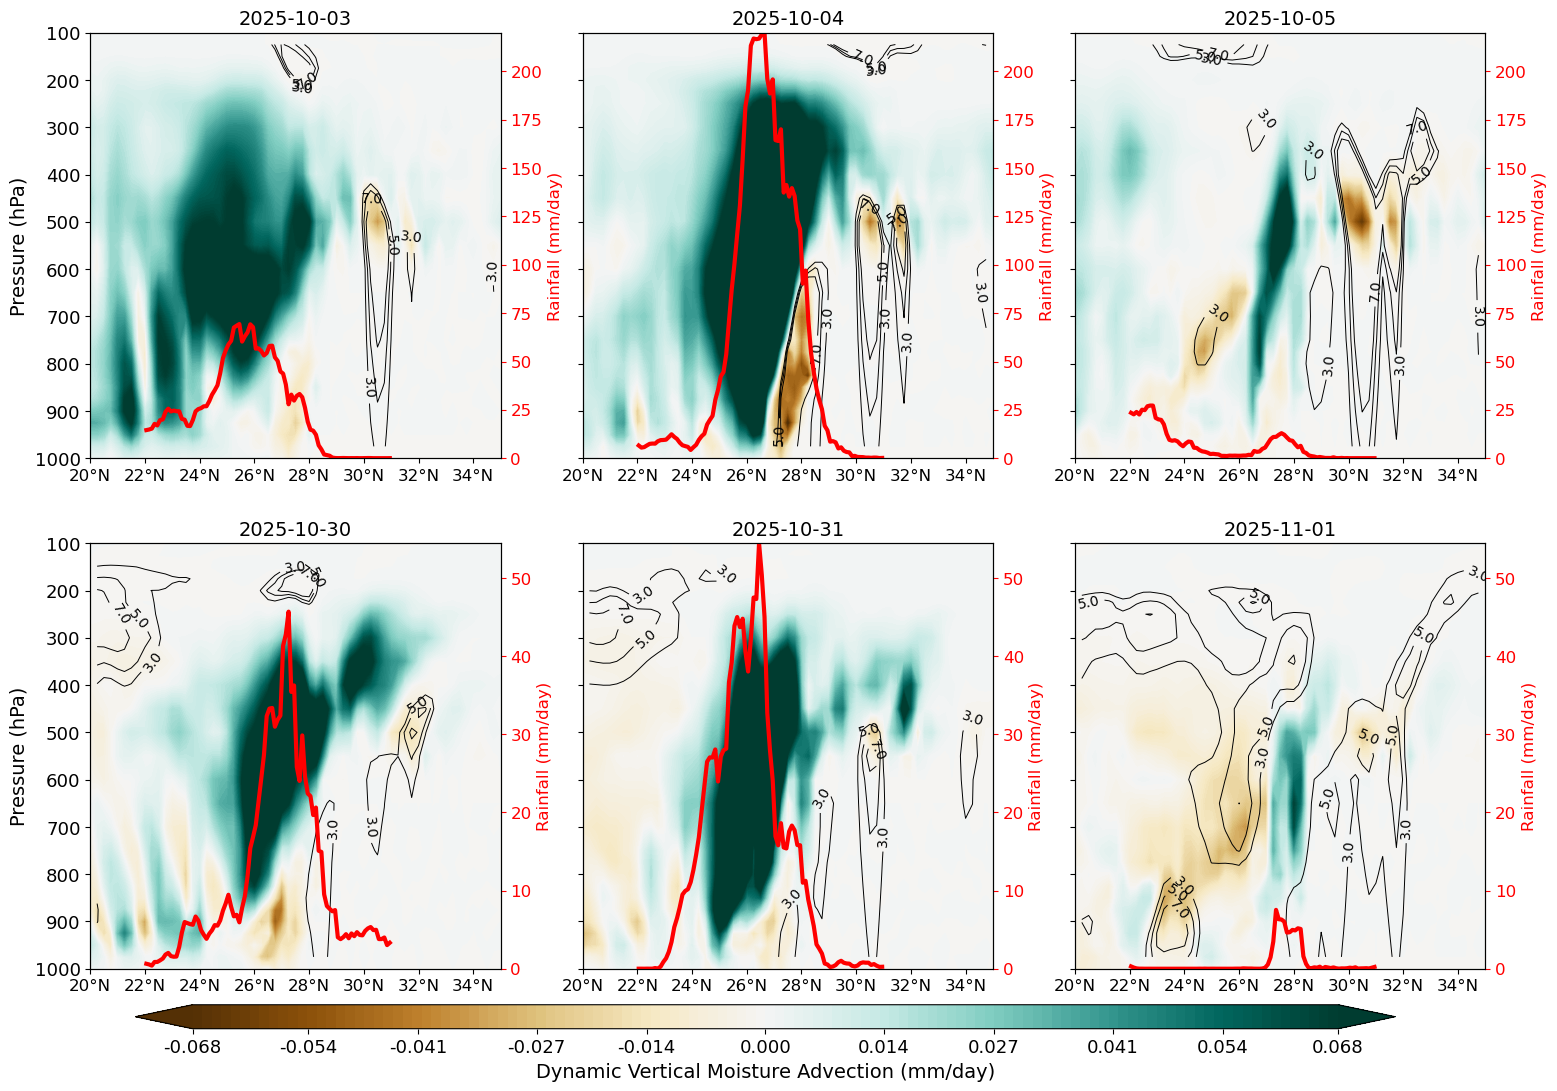

In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# CONSTANTS
g = 9.81                # Gravity (m/s²)
sec_day = 86400.0       # Seconds in a day
earth_radius = 6.371e6  # Earth radius (m)

# FUNCTIONS

def process_era(era, time_coord='valid_time'):
    """Compute dynamic moisture advection and Q1 heating"""
    # Sort descending for plotting (surface at bottom)
    era = era.sortby("pressure_level", ascending=False)
    era = era.sel(longitude=slice(84,88), latitude=slice(35,20))

    q = era['q']
    omega = era['w']
    T = era['t']
    u = era['u']
    v = era['v']

    # Dynamic Moisture Advection 
    dq_dp = q.differentiate('pressure_level')
    dyn = -(omega * dq_dp) / g
    dyn = dyn * sec_day
    dyn_cross = dyn.mean(dim='longitude')

    #Q1 Heating
    dT_dt = T.differentiate(time_coord) * sec_day
    lat_rad = np.deg2rad(era.latitude)
    dx = earth_radius * np.cos(lat_rad) * np.deg2rad(1)
    dy = earth_radius * np.deg2rad(1)
    dT_dx = T.differentiate('longitude') / dx
    dT_dy = T.differentiate('latitude') / dy
    adv_h = u * dT_dx + v * dT_dy
    dT_dp = T.differentiate('pressure_level') / 100.0
    adv_v = omega * dT_dp
    Q1 = (dT_dt + adv_h + adv_v) * sec_day
    Q1_cross = Q1.mean(dim='longitude')

    # Fix latitude & pressure for interpolation 
    Q1_cross = Q1_cross.sortby("latitude")
    
    # Temporarily sort pressure ascending for interpolation
    Q1_cross = Q1_cross.sortby("pressure_level", ascending=True)
    Q1_cross = Q1_cross.interpolate_na(dim="pressure_level", method="linear", fill_value="extrapolate")
    Q1_cross = Q1_cross.interpolate_na(dim="latitude", method="linear", fill_value="extrapolate")
    
    # Smooth with rolling mean
    Q1_cross = Q1_cross.rolling(latitude=3, pressure_level=3, center=True).mean()
    
    # Revert pressure back to descending for plotting
    Q1_cross = Q1_cross.sortby("pressure_level", ascending=False)

    return dyn_cross, Q1_cross

def load_rain(path):
    """Load and preprocess MSWEP rainfall data"""
    rain = xr.open_dataset(path)['precipitation']
    rain = rain.sortby('time')
    rain = rain.sel(lon=slice(84,88))
    if rain.lat[0] > rain.lat[-1]:
        rain = rain.sel(lat=slice(31,22))
    else:
        rain = rain.sel(lat=slice(22,31))
    rain_daily = rain.resample(time='1D').sum()
    rain_zonal = rain_daily.mean(dim='lon')
    return rain_zonal, float(rain_zonal.min()), float(rain_zonal.max())

# ============================================================
# 1️⃣ LOAD ERA5 NETCDF
# ============================================================
era_nc_file = "/Users/beekenshrestha/Downloads/RESEARCH/oct4/advection_4.nc"
era1 = xr.open_dataset(era_nc_file)
dyn1, Q1_1 = process_era(era1, time_coord='valid_time')
rain1, rain1_min, rain1_max = load_rain("/Users/beekenshrestha/Downloads/RESEARCH/oct4/MSWEP/merged.nc")

# ============================================================
# 2️⃣ LOAD ERA5 GRIB
# ============================================================
era_grib_file = "/Users/beekenshrestha/Downloads/RESEARCH/oct4/advection_31.grib"
era2 = xr.open_dataset(
    era_grib_file,
    engine="cfgrib",
    backend_kwargs={"filter_by_keys": {"typeOfLevel": "isobaricInhPa"}}
)

# Rename coordinates if needed
if "isobaricInhPa" in era2.coords:
    era2 = era2.rename({"isobaricInhPa": "pressure_level"})
if "lat" in era2.coords:
    era2 = era2.rename({"lat": "latitude"})
if "lon" in era2.coords:
    era2 = era2.rename({"lon": "longitude"})

dyn2, Q1_2 = process_era(era2, time_coord='time')
rain2, rain2_min, rain2_max = load_rain("/Users/beekenshrestha/Downloads/RESEARCH/oct4/MSWEP31/merged.nc")

# ============================================================
# 3️⃣ COLOR LEVELS (shared)
# ============================================================
vmax = np.nanpercentile(np.abs(
    np.concatenate([dyn1.values.flatten(), dyn2.values.flatten()])
), 95)
dyn_levels = np.linspace(-vmax, vmax, 121)
Q1_levels = np.arange(3, 7.1 + 0.01, 2)

# ============================================================
# 4️⃣ PANEL PLOTTING
# ============================================================
dates_row1 = ["2025-10-03","2025-10-04","2025-10-05"]
dates_row2 = ["2025-10-30","2025-10-31","2025-11-01"]

fig, axes = plt.subplots(2, 3, figsize=(18,12), sharey=True)
lat_ticks  = np.arange(20,35,2)
pres_ticks = np.arange(1000, 99, -100)  # descending

# ---- Top row: NetCDF ----
for i, day in enumerate(dates_row1):
    ax1 = axes[0, i]
    dyn_day = dyn1.sel(valid_time=day).mean('valid_time')
    Q1_day = Q1_1.sel(valid_time=day).mean('valid_time')

    cf = ax1.contourf(dyn_day.latitude, dyn_day.pressure_level, dyn_day, levels=dyn_levels, cmap='BrBG', extend='both')
    ax1.set_ylim(1000, 100)  # reversed
    cs = ax1.contour(Q1_day.latitude, Q1_day.pressure_level, Q1_day, levels=Q1_levels, colors='black', linewidths=0.7)
    ax1.clabel(cs, fmt="%.1f", fontsize=10)

    rain_day = rain1.sel(time=day)
    ax2 = ax1.twinx()
    ax2.plot(rain_day.lat, rain_day, color='red', linewidth=3)
    ax2.set_ylabel("Rainfall (mm/day)", color='red', fontsize=12)
    ax2.tick_params(axis='y', colors='red', labelsize=12)
    ax2.set_ylim(rain1_min, rain1_max)

    ax1.set_xticks(lat_ticks)
    ax1.set_xticklabels([f"{lat}°N" for lat in lat_ticks], fontsize=12)
    ax1.set_yticks(pres_ticks)
    ax1.tick_params(axis='y', labelsize=13)
    ax1.set_title(day, fontsize=14)

# ---- Bottom row: GRIB ----
for i, day in enumerate(dates_row2):
    ax1 = axes[1, i]
    dyn_day = dyn2.sel(time=day).mean('time')
    Q1_day = Q1_2.sel(time=day).mean('time')

    cf = ax1.contourf(dyn_day.latitude, dyn_day.pressure_level, dyn_day, levels=dyn_levels, cmap='BrBG', extend='both')
    ax1.set_ylim(1000, 100)  # reversed
    cs = ax1.contour(Q1_day.latitude, Q1_day.pressure_level, Q1_day, levels=Q1_levels, colors='black', linewidths=0.7)
    ax1.clabel(cs, fmt="%.1f", fontsize=10)

    rain_day = rain2.sel(time=day)
    ax2 = ax1.twinx()
    ax2.plot(rain_day.lat, rain_day, color='red', linewidth=3)
    ax2.set_ylabel("Rainfall (mm/day)", color='red', fontsize=12)
    ax2.tick_params(axis='y', colors='red', labelsize=12)
    ax2.set_ylim(rain2_min, rain2_max)

    ax1.set_xticks(lat_ticks)
    ax1.set_xticklabels([f"{lat}°N" for lat in lat_ticks], fontsize=12)
    ax1.set_yticks(pres_ticks)
    ax1.tick_params(axis='y', labelsize=13)
    ax1.set_title(day, fontsize=14)

axes[0,0].set_ylabel("Pressure (hPa)", fontsize=14)
axes[1,0].set_ylabel("Pressure (hPa)", fontsize=14)

# ============================================================
# COLORBAR
# ============================================================
plt.subplots_adjust(bottom=0.1)
cax = fig.add_axes([0.15,0.05,0.7,0.02])
cbar = fig.colorbar(cf, cax=cax, orientation='horizontal', format=FormatStrFormatter('%.3f'))
cbar.set_label("Dynamic Vertical Moisture Advection (mm/day)", fontsize=14)
cbar.ax.tick_params(labelsize=13)
cbar.set_ticks(np.round(np.linspace(-vmax, vmax, 11), 3))

# ============================================================
# SAVE & SHOW
# ============================================================
plt.savefig("/Users/beekenshrestha/Downloads/RESEARCH/oct4/output/2event_Advection.png",
            dpi=1250, bbox_inches='tight')
plt.show()

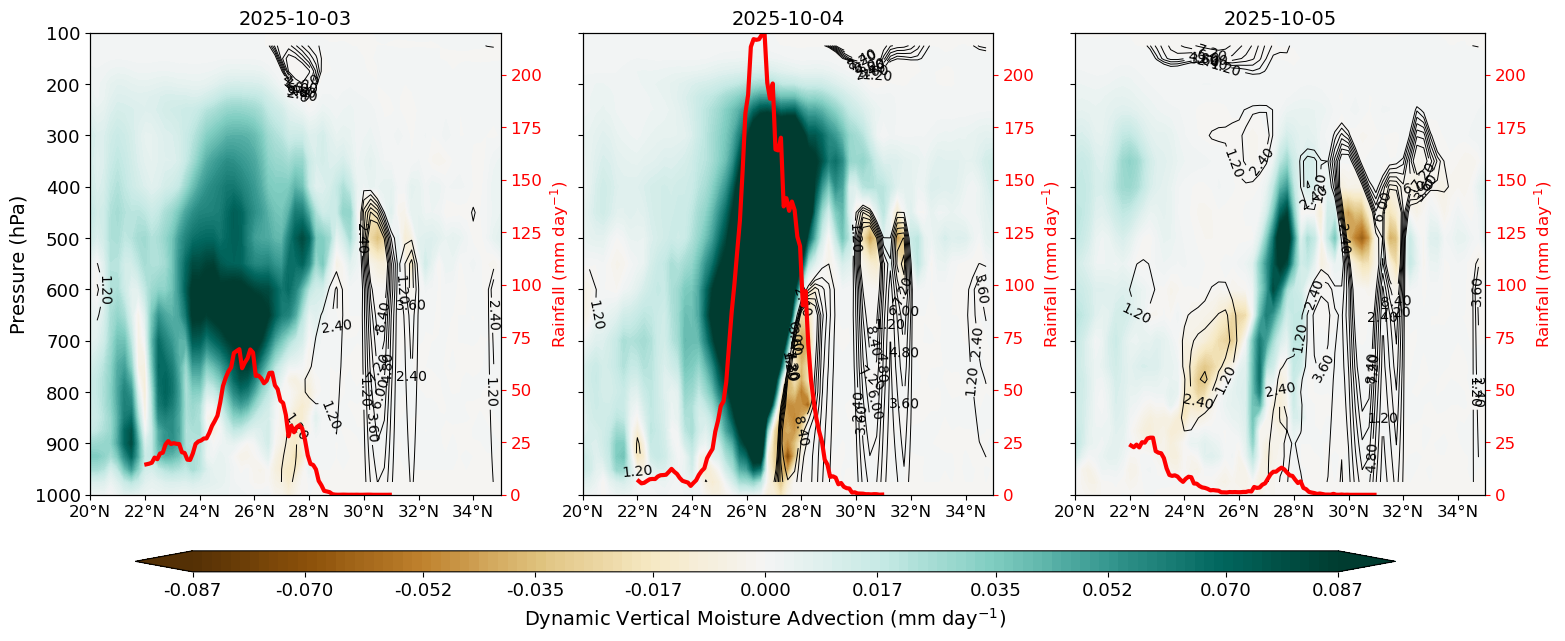

In [27]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# ============================================================
# CONSTANTS
# ============================================================
g = 9.81                # Gravity (m/s²)
sec_day = 86400.0       # Seconds in a day
earth_radius = 6.371e6  # Earth radius (m)

# ============================================================
# 1️⃣ LOAD ERA5 DATA
# ============================================================
era_file = "/Users/beekenshrestha/Downloads/RESEARCH/oct4/advection_4.nc"
era = xr.open_dataset(era_file)

# Sort pressure levels and select domain
era = era.sortby("pressure_level")
era = era.sel(longitude=slice(84,88), latitude=slice(35,20))

q = era['q']
omega = era['w']
T = era['t']
u = era['u']
v = era['v']

# ============================================================
# 2️⃣ DYNAMIC VERTICAL MOISTURE ADVECTION (SHADED)
# ============================================================
dq_dp = q.differentiate('pressure_level')
dyn_moist = -(omega * dq_dp) / g
dyn_moist = dyn_moist * sec_day  # Convert to mm/day

dyn_cross = dyn_moist.mean(dim='longitude')  # Zonal mean

# ============================================================
# 3️⃣ DIABATIC HEATING RATE Q1
# ============================================================
dT_dt = T.differentiate('valid_time') * sec_day

lat_rad = np.deg2rad(era.latitude)
dx = earth_radius * np.cos(lat_rad) * np.deg2rad(1)
dy = earth_radius * np.deg2rad(1)

dT_dx = T.differentiate('longitude') / dx
dT_dy = T.differentiate('latitude') / dy
adv_h = u * dT_dx + v * dT_dy

dT_dp = T.differentiate('pressure_level') / 100.0
adv_v = omega * dT_dp

Q1 = (dT_dt + adv_h + adv_v) * sec_day
Q1_cross = Q1.mean(dim='longitude')

# Fix latitude order and interpolate NaNs
Q1_cross = Q1_cross.sortby("latitude")
Q1_cross = Q1_cross.interpolate_na(dim="pressure_level", method="linear", fill_value="extrapolate")
Q1_cross = Q1_cross.interpolate_na(dim="latitude", method="linear", fill_value="extrapolate")

# Smooth for journal-style contours
Q1_cross = Q1_cross.rolling(latitude=3, pressure_level=3, center=True).mean()

# ============================================================
# 4️⃣ MSWEP RAINFALL
# ============================================================
mswep_file = "/Users/beekenshrestha/Downloads/RESEARCH/oct4/MSWEP/merged.nc"
rain = xr.open_dataset(mswep_file)['precipitation']

rain = rain.sortby('time')
rain = rain.sel(lon=slice(84,88))

if rain.lat[0] > rain.lat[-1]:
    rain = rain.sel(lat=slice(31,22))
else:
    rain = rain.sel(lat=slice(22,31))

rain_daily = rain.resample(time='1D').sum()
rain_zonal = rain_daily.mean(dim='lon')

rain_min = float(rain_zonal.min())
rain_max = float(rain_zonal.max())

# ============================================================
# 5️⃣ COLOR LEVELS
# ============================================================
vmax = np.nanpercentile(np.abs(dyn_cross), 95)
dyn_levels = np.linspace(-vmax, vmax, 121)
Q1_levels = np.arange(1.2, 9.0, 1.2)

# ============================================================
# 6️⃣ PLOTTING
# ============================================================
dates = ["2025-10-03","2025-10-04","2025-10-05"]
fig, axes = plt.subplots(1, 3, figsize=(18,7), sharey=True)

lat_ticks  = np.arange(20,35,2)
pres_ticks = np.arange(1000, 99, -100)

for i, day in enumerate(dates):
    ax1 = axes[i]

    dyn_day = dyn_cross.sel(valid_time=day).mean('valid_time')
    Q1_day = Q1_cross.sel(valid_time=day).mean('valid_time')

    # ---- shaded dynamic moisture advection ----
    cf = ax1.contourf(
        dyn_day.latitude,
        dyn_day.pressure_level,
        dyn_day,
        levels=dyn_levels,
        cmap='BrBG',
        extend='both'
    )
    ax1.invert_yaxis()

    # ---- Q1 contours ----
    cs = ax1.contour(
        Q1_day.latitude,
        Q1_day.pressure_level,
        Q1_day,
        levels=Q1_levels,
        colors='black',
        linewidths=0.7
    )
    ax1.clabel(cs, fmt="%.2f", fontsize=10)

    # ---- rainfall overlay ----
    rain_day = rain_zonal.sel(time=day)
    ax2 = ax1.twinx()
    ax2.plot(rain_day.lat, rain_day, color='red', linewidth=3)
    ax2.set_ylabel("Rainfall (mm day$^{-1}$)", color='red', fontsize=12)
    ax2.tick_params(axis='y', colors='red', labelsize=12)
    ax2.set_ylim(rain_min, rain_max)

    ax1.set_xticks(lat_ticks)
    ax1.set_xticklabels([f"{lat}°N" for lat in lat_ticks], fontsize=12)
    ax1.set_yticks(pres_ticks)
    ax1.tick_params(axis='y', labelsize=13)
    ax1.set_xlabel("", fontsize=14)
    ax1.set_title(day, fontsize=14)

axes[0].set_ylabel("Pressure (hPa)", fontsize=14)

# ============================================================
# COLORBAR
# ============================================================
plt.subplots_adjust(bottom=0.22)
cax = fig.add_axes([0.15,0.11,0.70,0.03])
cbar = fig.colorbar(cf, cax=cax, orientation='horizontal', format=FormatStrFormatter('%.3f'))
cbar.set_label("Dynamic Vertical Moisture Advection (mm day$^{-1}$)", fontsize=14)
cbar.ax.tick_params(labelsize=13)
cbar.set_ticks(np.round(np.linspace(-vmax, vmax, 11), 3))

plt.savefig("/Users/beekenshrestha/Downloads/RESEARCH/oct4/output/4Advection.png", dpi=1250, bbox_inches='tight')
plt.show()


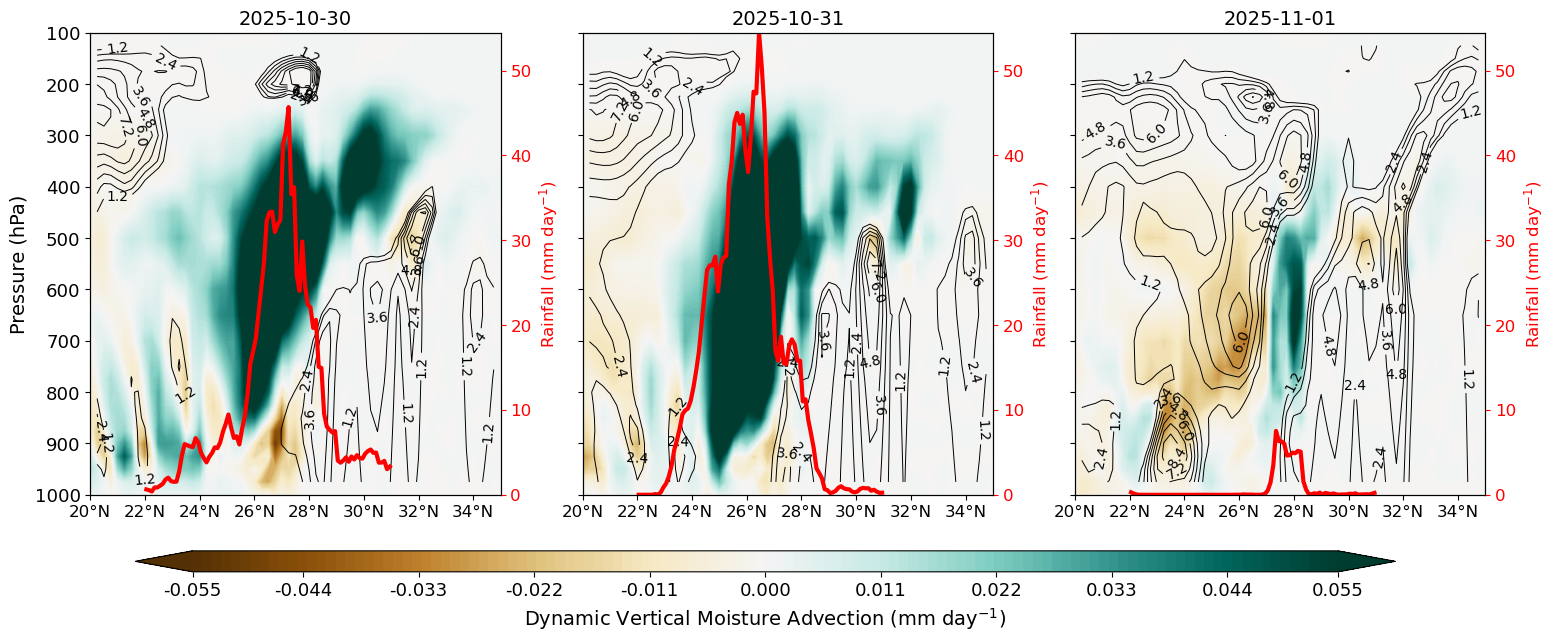

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# ============================================================
# CONSTANTS
# ============================================================
g = 9.81                # Gravity (m/s²)
sec_day = 86400.0       # Seconds in a day
earth_radius = 6.371e6  # Earth radius (m)

# ============================================================
# 1️⃣ LOAD ERA5 GRIB DATA
# ============================================================
era_file = "/Users/beekenshrestha/Downloads/RESEARCH/oct4/advection_31.grib"
era = xr.open_dataset(
    era_file,
    engine="cfgrib",
    backend_kwargs={"filter_by_keys": {"typeOfLevel": "isobaricInhPa"}}
)

# Rename coordinates if needed
if "isobaricInhPa" in era.coords:
    era = era.rename({"isobaricInhPa": "pressure_level"})
if "lat" in era.coords:
    era = era.rename({"lat": "latitude"})
if "lon" in era.coords:
    era = era.rename({"lon": "longitude"})

# Use 'time' as the main time coordinate
time_coord = 'time'

# Sort pressure levels and select Nepal region
era = era.sortby("pressure_level")
era = era.sel(longitude=slice(84,88), latitude=slice(35,20))

q = era['q']
omega = era['w']
T = era['t']
u = era['u']
v = era['v']

# ============================================================
# 2️⃣ DYNAMIC VERTICAL MOISTURE ADVECTION (SHADED)
# ============================================================
dq_dp = q.differentiate('pressure_level')
dyn_moist = -(omega * dq_dp) / g
dyn_moist = dyn_moist * sec_day  # Convert to mm/day

dyn_cross = dyn_moist.mean(dim='longitude')  # Zonal mean

# ============================================================
# 3️⃣ DIABATIC HEATING RATE Q1
# ============================================================
dT_dt = T.differentiate(time_coord) * sec_day

lat_rad = np.deg2rad(era.latitude)
dx = earth_radius * np.cos(lat_rad) * np.deg2rad(1)
dy = earth_radius * np.deg2rad(1)

dT_dx = T.differentiate('longitude') / dx
dT_dy = T.differentiate('latitude') / dy
adv_h = u * dT_dx + v * dT_dy

dT_dp = T.differentiate('pressure_level') / 100.0
adv_v = omega * dT_dp

Q1 = (dT_dt + adv_h + adv_v) * sec_day
Q1_cross = Q1.mean(dim='longitude')

# Fix latitude order and interpolate NaNs
Q1_cross = Q1_cross.sortby("latitude")
Q1_cross = Q1_cross.interpolate_na(dim="pressure_level", method="linear", fill_value="extrapolate")
Q1_cross = Q1_cross.interpolate_na(dim="latitude", method="linear", fill_value="extrapolate")

# Smooth for journal-style contours
Q1_cross = Q1_cross.rolling(latitude=3, pressure_level=3, center=True).mean()

# ============================================================
# 4️⃣ MSWEP RAINFALL
# ============================================================
mswep_file = "/Users/beekenshrestha/Downloads/RESEARCH/oct4/MSWEP31/merged.nc"
rain = xr.open_dataset(mswep_file)['precipitation']

rain = rain.sortby('time')
rain = rain.sel(lon=slice(84,88))

if rain.lat[0] > rain.lat[-1]:
    rain = rain.sel(lat=slice(31,22))
else:
    rain = rain.sel(lat=slice(22,31))

rain_daily = rain.resample(time='1D').sum()
rain_zonal = rain_daily.mean(dim='lon')

rain_min = float(rain_zonal.min())
rain_max = float(rain_zonal.max())

# ============================================================
# 5️⃣ COLOR LEVELS
# ============================================================
vmax = np.nanpercentile(np.abs(dyn_cross), 95)
dyn_levels = np.linspace(-vmax, vmax, 121)
Q1_levels = np.arange(1.2, 9.0, 1.2)

# ============================================================
# 6️⃣ PLOTTING
# ============================================================
dates = ["2025-10-30","2025-10-31","2025-11-01"]
fig, axes = plt.subplots(1, 3, figsize=(18,7), sharey=True)

lat_ticks  = np.arange(20,35,2)
pres_ticks = np.arange(1000, 99, -100)

for i, day in enumerate(dates):
    ax1 = axes[i]

    dyn_day = dyn_cross.sel({time_coord: day}).mean(time_coord)
    Q1_day = Q1_cross.sel({time_coord: day}).mean(time_coord)

    # ---- shaded dynamic moisture advection ----
    cf = ax1.contourf(
        dyn_day.latitude,
        dyn_day.pressure_level,
        dyn_day,
        levels=dyn_levels,
        cmap='BrBG',
        extend='both'
    )
    ax1.invert_yaxis()

    # ---- Q1 contours ----
    cs = ax1.contour(
        Q1_day.latitude,
        Q1_day.pressure_level,
        Q1_day,
        levels=Q1_levels,
        colors='black',
        linewidths=0.7
    )
    ax1.clabel(cs, fmt="%.1f", fontsize=10)

    # ---- rainfall overlay ----
    rain_day = rain_zonal.sel(time=day)
    ax2 = ax1.twinx()
    ax2.plot(rain_day.lat, rain_day, color='red', linewidth=3)
    ax2.set_ylabel("Rainfall (mm day$^{-1}$)", color='red', fontsize=12)
    ax2.tick_params(axis='y', colors='red', labelsize=12)
    ax2.set_ylim(rain_min, rain_max)

    ax1.set_xticks(lat_ticks)
    ax1.set_xticklabels([f"{lat}°N" for lat in lat_ticks], fontsize=12)
    ax1.set_yticks(pres_ticks)
    ax1.tick_params(axis='y', labelsize=13)
    ax1.set_xlabel("", fontsize=14)
    ax1.set_title(day, fontsize=14)

axes[0].set_ylabel("Pressure (hPa)", fontsize=14)

# ============================================================
# COLORBAR
# ============================================================
plt.subplots_adjust(bottom=0.22)
cax = fig.add_axes([0.15,0.11,0.70,0.03])
cbar = fig.colorbar(cf, cax=cax, orientation='horizontal', format=FormatStrFormatter('%.3f'))
cbar.set_label("Dynamic Vertical Moisture Advection (mm day$^{-1}$)", fontsize=14)
cbar.ax.tick_params(labelsize=13)
cbar.set_ticks(np.round(np.linspace(-vmax, vmax, 11), 3))

plt.savefig("/Users/beekenshrestha/Downloads/RESEARCH/oct4/output/31Advection.png",
            dpi=1250, bbox_inches='tight')
plt.show()

/var/folders/jv/b201cczs5pj2c3krlgyf3fs80000gn/T/ipykernel_1939/1897198602.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0.07,1,1])


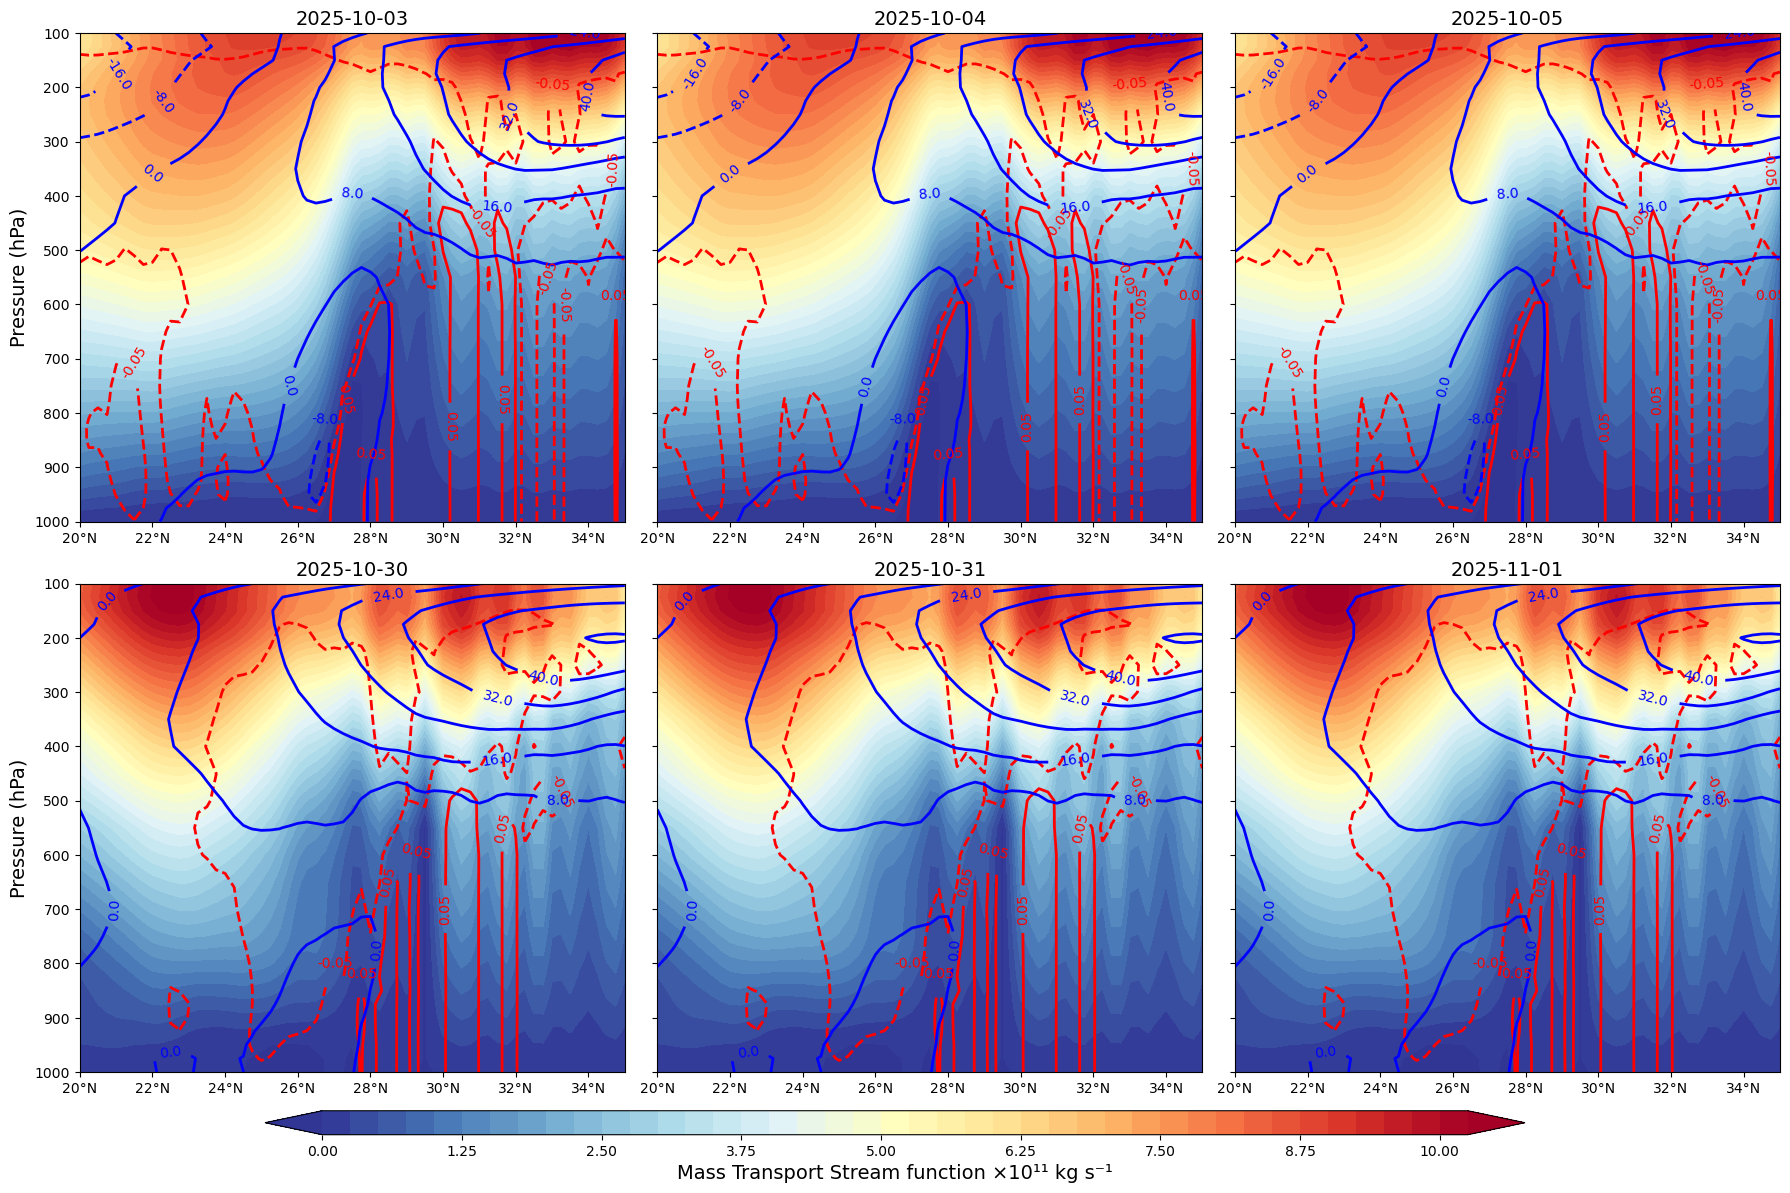

In [2]:
# ============================================================
# STREAMFUNCTION, VERTICAL VELOCITY & ZONAL WIND PLOT
# ============================================================

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ---------------- CONSTANTS ----------------
g = 9.81
earth_radius = 6.371e6

# ---------------- FUNCTIONS ----------------
def compute_streamfunction(ds, time_coord):
    """Compute mass streamfunction ψ from ERA5 winds"""
    ds = ds.sortby("pressure_level", ascending=False)
    ds = ds.sel(longitude=slice(84,88), latitude=slice(35,20))
    v = ds['v'].mean(dim='longitude')
    v_mean = v.mean(dim=time_coord)

    lat = v_mean.latitude.values
    pressure = v_mean.pressure_level.values
    lat_rad = np.deg2rad(lat)

    v_np = v_mean.values
    psi = np.zeros_like(v_np)

    for j in range(len(lat)):
        cosphi = np.cos(lat_rad[j])
        for k in range(1, len(pressure)):
            dp = (pressure[k-1] - pressure[k]) * 100.0  # hPa → Pa
            psi[k, j] = psi[k-1, j] + (2 * np.pi * earth_radius * cosphi / g) * v_np[k, j] * dp

    psi = psi / 1e11  # scale for plotting
    return lat, pressure, psi

def zonal_mean(var, ds, time_coord):
    """Compute zonal mean and time average"""
    var_mean = var.mean(dim='longitude')
    var_mean = var_mean.mean(dim=time_coord)
    return var_mean

# ---------------- LOAD DATA ----------------
# ERA5 NetCDF
era_nc_file = "/Users/beekenshrestha/Downloads/RESEARCH/oct4/advection_4.nc"
era1 = xr.open_dataset(era_nc_file)
era1 = era1.sortby("pressure_level", ascending=False)
era1 = era1.sel(longitude=slice(84,88), latitude=slice(35,20))

# Compute zonal means
psi1_lat, psi1_pres, psi1 = compute_streamfunction(era1, time_coord='valid_time')
omega1 = zonal_mean(era1['w'], era1, 'valid_time')  # m/s
u1 = zonal_mean(era1['u'], era1, 'valid_time')      # m/s

# ERA5 GRIB
era_grib_file = "/Users/beekenshrestha/Downloads/RESEARCH/oct4/advection_31.grib"
era2 = xr.open_dataset(era_grib_file, engine="cfgrib",
                       backend_kwargs={"filter_by_keys": {"typeOfLevel": "isobaricInhPa"}})
if "isobaricInhPa" in era2.coords:
    era2 = era2.rename({"isobaricInhPa": "pressure_level"})
if "lat" in era2.coords:
    era2 = era2.rename({"lat": "latitude"})
if "lon" in era2.coords:
    era2 = era2.rename({"lon": "longitude"})
era2 = era2.sortby("pressure_level", ascending=False)
era2 = era2.sel(longitude=slice(84,88), latitude=slice(35,20))

psi2_lat, psi2_pres, psi2 = compute_streamfunction(era2, time_coord='time')
omega2 = zonal_mean(era2['w'], era2, 'time')  # m/s
u2 = zonal_mean(era2['u'], era2, 'time')      # m/s

# ---------------- PLOTTING ----------------
dates_row1 = ["2025-10-03","2025-10-04","2025-10-05"]
dates_row2 = ["2025-10-30","2025-10-31","2025-11-01"]

fig, axes = plt.subplots(2, 3, figsize=(18,12), sharey=True)
lat_ticks  = np.arange(20,36,2)
pres_ticks = np.arange(1000, 99, -100)

# Define vertical velocity contour levels (large gap)
omega_levels = np.arange(-0.05, 0.06, 0.1)  # 0.01 m/s spacing
# You can increase step for even fewer lines: e.g., 0.02

# ---- Top row: NetCDF ----
for i, day in enumerate(dates_row1):
    ax = axes[0, i]

    # Streamfunction (shaded)
    cf = ax.contourf(psi1_lat, psi1_pres, psi1, cmap='RdYlBu_r', levels=50 , extend='both')
    
    # Vertical velocity (red contour lines, thick, large gap)
    cs_omega = ax.contour(omega1.latitude, omega1.pressure_level, omega1,
                          levels=omega_levels, colors='red', linewidths=2.0)
    ax.clabel(cs_omega, fmt="%.2f", fontsize=10)

    # Zonal wind (blue contour lines)
    cs_u = ax.contour(u1.latitude, u1.pressure_level, u1,
                      colors='blue', linewidths=2.0)
    ax.clabel(cs_u, fmt="%.1f", fontsize=10)

    ax.set_ylim(1000, 100)
    ax.set_xticks(lat_ticks)
    ax.set_xticklabels([f"{lat}°N" for lat in lat_ticks])
    ax.set_yticks(pres_ticks)
    ax.set_title(day, fontsize=14)

# ---- Bottom row: GRIB ----
for i, day in enumerate(dates_row2):
    ax = axes[1, i]

    cf = ax.contourf(psi2_lat, psi2_pres, psi2, cmap='RdYlBu_r', levels=50, extend='both')
    
    cs_omega = ax.contour(omega2.latitude, omega2.pressure_level, omega2,
                          levels=omega_levels, colors='red', linewidths=2.0)
    ax.clabel(cs_omega, fmt="%.2f", fontsize=10)
    
    cs_u = ax.contour(u2.latitude, u2.pressure_level, u2,
                      colors='blue', linewidths=2.0)
    ax.clabel(cs_u, fmt="%.1f", fontsize=10)

    ax.set_ylim(1000, 100)
    ax.set_xticks(lat_ticks)
    ax.set_xticklabels([f"{lat}°N" for lat in lat_ticks])
    ax.set_yticks(pres_ticks)
    ax.set_title(day, fontsize=14)

axes[0,0].set_ylabel("Pressure (hPa)", fontsize=14)
axes[1,0].set_ylabel("Pressure (hPa)", fontsize=14)

# Colorbar for streamfunction
cbar_ax = fig.add_axes([0.15,0.05,0.7,0.02])
cbar = fig.colorbar(cf, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Mass Transport Stream function ×10¹¹ kg s⁻¹", fontsize=14)

plt.tight_layout(rect=[0,0.07,1,1])

# save figure
#plt.savefig("/Users/beekenshrestha/Downloads/RESEARCH/Sankhuwasava/Output/Mass_Transport_Stream_function.png", dpi=1250, bbox_inches='tight')
plt.show()

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import ipywidgets as widgets
from IPython.display import display, clear_output

# ============================================================
# CONSTANTS
# ============================================================
g = 9.81
sec_day = 86400.0
earth_radius = 6.371e6

# ============================================================
# ERA5 DATA
# ============================================================
era_file = "/Users/beekenshrestha/Downloads/RESEARCH/oct4/advection_4.nc"
era = xr.open_dataset(era_file)

era = era.sortby("pressure_level")
era = era.sel(longitude=slice(84,88), latitude=slice(35,20))

q = era['q']
omega = era['w']
T = era['t']
u = era['u']
v = era['v']

# ============================================================
# DYNAMIC MOISTURE ADVECTION
# ============================================================
dq_dp = q.differentiate('pressure_level')
dyn_moist = -(omega * dq_dp) / g * sec_day
dyn_cross = dyn_moist.mean(dim='longitude')

# ============================================================
# Q1 HEATING
# ============================================================
dT_dt = T.differentiate('valid_time') * sec_day

lat_rad = np.deg2rad(era.latitude)
dx = earth_radius * np.cos(lat_rad) * np.deg2rad(1)
dy = earth_radius * np.deg2rad(1)

dT_dx = T.differentiate('longitude') / dx
dT_dy = T.differentiate('latitude') / dy

adv_h = u * dT_dx + v * dT_dy
dT_dp = T.differentiate('pressure_level')
adv_v = omega * dT_dp

Q1 = (dT_dt + adv_h + adv_v) * sec_day
Q1_cross = Q1.mean(dim='longitude')

# ============================================================
# EXTRA VARIABLES
# ============================================================
omega_cross = omega.mean(dim='longitude') * 100   # hPa/s
q_cross = q.mean(dim='longitude') * 1000          # g/kg

# ============================================================
# MSWEP RAIN
# ============================================================
mswep_file = "/Users/beekenshrestha/Downloads/RESEARCH/oct4/MSWEP/merged.nc"
rain = xr.open_dataset(mswep_file)['precipitation']

rain = rain.sortby('time').sel(lon=slice(84,88))

if rain.lat[0] > rain.lat[-1]:
    rain = rain.sel(lat=slice(31,22))
else:
    rain = rain.sel(lat=slice(22,31))

rain_daily = rain.resample(time='1D').sum()
rain_zonal = rain_daily.mean(dim='lon')

rain_min = float(rain_zonal.min())
rain_max = float(rain_zonal.max())

# ============================================================
# COLOR LEVELS
# ============================================================
vmax = np.nanpercentile(np.abs(dyn_cross), 95)
dyn_levels = np.linspace(-vmax, vmax, 101)

Q1_levels = np.arange(0, 9, 3)

omega_levels = np.linspace(
    -np.nanpercentile(np.abs(omega_cross), 95),
     np.nanpercentile(np.abs(omega_cross), 95), 101
)

q_levels = np.linspace(0, np.nanpercentile(q_cross, 95), 100)

# ============================================================
# INTERFACE CONTROLS
# ============================================================
dates = ["2025-10-03","2025-10-04","2025-10-05"]

variable_selector = widgets.Dropdown(
    options=[
        ("Dynamic Moisture","dyn"),
        ("Diabatic Heating Q1","Q1"),
        ("Vertical Velocity ω","omega"),
        ("Specific Humidity q","q")
    ],
    description="Variable:"
)

date_selector = widgets.Dropdown(
    options=dates,
    description="Date:"
)

time_slider = widgets.IntSlider(
    value=0, min=0, max=23, step=1, description="Hour:"
)

play = widgets.Play(
    interval=500, value=0, min=0, max=23, step=1
)
widgets.jslink((play,'value'),(time_slider,'value'))

output = widgets.Output()

# ============================================================
# COLORBAR SETTINGS
# ============================================================
cbar_location = "bottom"   # bottom/top/left/right
cbar_pad = 0.07
cbar_shrink = 0.9
cbar_fraction = 0.09
cbar_aspect = 40

# ============================================================
# PLOT FUNCTION
# ============================================================
def update_plot(change=None):
    with output:
        clear_output(wait=True)

        day = date_selector.value
        t_index = time_slider.value
        var = variable_selector.value

        # ---------------- variable selection ----------------
        if var == "dyn":
            data_all = dyn_cross.sel(valid_time=day)
            levels = dyn_levels
            cmap = "BrBG"
            label = "Dynamic Moisture (mm/hour)"
        elif var == "Q1":
            data_all = Q1_cross.sel(valid_time=day)
            levels = Q1_levels
            cmap = "coolwarm"
            label = "Q1 Heating (K/hour)"
        elif var == "omega":
            data_all = omega_cross.sel(valid_time=day)
            levels = omega_levels
            cmap = "PuOr"
            label = "Vertical Velocity (hPa/s)"
        else:
            data_all = q_cross.sel(valid_time=day)
            levels = q_levels
            cmap = "YlGnBu"
            label = "Specific Humidity (g/kg)"

        data = data_all.isel(valid_time=t_index)
        rain_day = rain_zonal.sel(time=day)

        # ---------------- plotting ----------------
        fig, ax1 = plt.subplots(figsize=(8,6))

        cf = ax1.contourf(
            data.latitude,
            data.pressure_level,
            data,
            levels=levels,
            cmap=cmap,
            extend='both'
        )

        ax1.invert_yaxis()

        # Rainfall overlay
        ax2 = ax1.twinx()
        ax2.plot(rain_day.lat, rain_day, color='red', linewidth=3)
        ax2.set_ylim(rain_min, rain_max)
        ax2.set_ylabel("Rainfall (mm/day)", color='red')

        ax1.set_ylabel("Pressure (hPa)")

        # ---------------- x-ticks with °N ----------------
        lat_ticks = np.linspace(float(data.latitude.min()), float(data.latitude.max()), 6)
        ax1.set_xticks(lat_ticks)
        ax1.set_xticklabels([f"{int(tick)}°N" for tick in lat_ticks])

        ax1.set_title(f"{label} | {day} | Hour {t_index:02d}")

        # ---------------- colorbar ----------------
        orientation = "horizontal" if cbar_location in ["bottom","top"] else "vertical"

        cbar = plt.colorbar(
            cf, ax=ax1, orientation=orientation,
            location=cbar_location,
            pad=cbar_pad,
            shrink=cbar_shrink,
            fraction=cbar_fraction,
            aspect=cbar_aspect
        )
        cbar.set_label(label)

        # Format tick labels to 2 decimals
        if orientation == "vertical":
            cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        else:
            cbar.ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

        plt.show()

# ============================================================
# EVENTS
# ============================================================
variable_selector.observe(update_plot, 'value')
date_selector.observe(update_plot, 'value')
time_slider.observe(update_plot, 'value')

# ============================================================
# DISPLAY PANEL
# ============================================================
control_panel = widgets.VBox([
    widgets.HBox([variable_selector, date_selector]),
    widgets.HBox([play, time_slider])
])

display(control_panel, output)

update_plot()


Output()